In [ ]:
#%% Load Library

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.metrics import mean_squared_error
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

In [ ]:
#%% Function

def createXY(dataset,n_past):
    dataX = []
    dataY = []
    for i in range(n_past, len(dataset)):
            dataX.append(dataset[i - n_past:i, 0:dataset.shape[1]])
            dataY.append(dataset[i,0])
    return np.array(dataX),np.array(dataY) 

def prepare_data(dir, store_id):
    df = pd.read_csv(dir,parse_dates = ["date"], index_col = [0])
    df = df[df['store_id'] == store_id]
    df = df.drop(columns=['count','store_id'])
    for col in df.columns:
        if df[col].dtype == bool:
            df[col] = df[col].astype(int)

    test_split=round(len(df)*0.20)
    df_for_training=df[:-test_split]
    df_for_testing=df[-test_split:]
    

    df_for_training_scaled = scaler.fit_transform(df_for_training)
    df_for_testing_scaled=scaler.transform(df_for_testing)
    trainX,trainY=createXY(df_for_training_scaled,30)

    testX,testY=createXY(df_for_testing_scaled,30)
    return trainX, trainY, testX, testY

def build_model(optimizer='adam'):
    grid_model = Sequential()
    grid_model.add(LSTM(50, return_sequences=True, input_shape=(30, 64)))
    grid_model.add(LSTM(50))
    grid_model.add(Dropout(0.2))
    grid_model.add(Dense(1))

    grid_model.compile(loss='mse', optimizer=optimizer)
    return grid_model

def train_model(model, train_x, train_y):

    grid_model = KerasRegressor(build_fn=model, verbose=1)
    parameters = {'batch_size': [16, 20],
                'epochs': [8, 10],
                'optimizer': ['adam', 'Adadelta']}

    grid_search = GridSearchCV(estimator=grid_model,
                            param_grid=parameters,
                            cv=2)
    grid_search = grid_search.fit(train_x, train_y)

    return grid_search

In [ ]:
#%% Load Library

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [ ]:
#%% Function

def createXY(dataset,n_past):
    dataX = []
    dataY = []
    for i in range(n_past, len(dataset)):
            dataX.append(dataset[i - n_past:i, 0:dataset.shape[1]])
            dataY.append(dataset[i,0])
    return np.array(dataX),np.array(dataY) 

def prepare_data(dir, store_id):
    df = pd.read_csv(dir,parse_dates = ["date"], index_col = [0])
    df = df[df['store_id'] == store_id]
    df = df.drop(columns=['count','store_id'])
    for col in df.columns:
        if df[col].dtype == bool:
            df[col] = df[col].astype(int)

    test_split=round(len(df)*0.20)
    df_for_training=df[:-test_split]
    df_for_testing=df[-test_split:]
    

    df_for_training_scaled = scaler.fit_transform(df_for_training)
    df_for_testing_scaled=scaler.transform(df_for_testing)
    trainX,trainY=createXY(df_for_training_scaled,30)

    testX,testY=createXY(df_for_testing_scaled,30)
    return trainX, trainY, testX, testY

def build_model(optimizer='adam'):
    grid_model = Sequential()
    grid_model.add(LSTM(50, return_sequences=True, input_shape=(30, 64)))
    grid_model.add(LSTM(50))
    grid_model.add(Dropout(0.2))
    grid_model.add(Dense(1))

    grid_model.compile(loss='mse', optimizer=optimizer)
    return grid_model

def train_model(model, train_x, train_y):

    grid_model = KerasRegressor(build_fn=model, verbose=1)
    parameters = {'batch_size': [16, 20],
                'epochs': [8, 10],
                'optimizer': ['adam', 'Adadelta']}

    grid_search = GridSearchCV(estimator=grid_model,
                            param_grid=parameters,
                            cv=2)
    grid_search = grid_search.fit(train_x, train_y)

    return grid_search

Training begin CA_1--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 11ms/step - loss: 0.0503
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0209
Epoch 3/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0163
Epoch 4/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0136
Epoch 5/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0098
Epoch 6/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0077
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0077
Epoch 8/8
47/47 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 13ms/step - loss: 0.0331
Epoch 2/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0148
Epoch 3/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0134
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0103
Epoch 5/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0077
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0070
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0064
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 4s 14ms/step - loss: 0.0513
Epoch 2/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0200
Epoch 3/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0169
Epoch 4/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0128
Epoch 5/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0100
Epoch 6/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0090
Epoch 7/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0074
Epoch 8/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0068
Epoch 9/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0074
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 16ms/step - loss: 0.0293
Epoch 2/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0150
Epoch 3/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0120
Epoch 4/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0103
Epoch 5/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0068
Epoch 6/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0070
Epoch 7/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0059
Epoch 8/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0062
Epoch 9/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0056
Epoch 10/10
38/38 [==============================] - 1s 6ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
75/75 [==============================] - 4s 15ms/step - loss: 0.0266
Epoch 2/10
75/75 [==============================] - 1s 14ms/step - loss: 0.0139
Epoch 3/10
75/75 [==============================] - 1s 13ms/step - loss: 0.0088
Epoch 4/10
75/75 [==============================] - 1s 11ms/step - loss: 0.0067
Epoch 5/10
75/75 [==============================] - 1s 12ms/step - loss: 0.0066
Epoch 6/10
75/75 [==============================] - 1s 14ms/step - loss: 0.0059
Epoch 7/10
75/75 [==============================] - 1s 14ms/step - loss: 0.0060
Epoch 8/10
75/75 [==============================] - 1s 14ms/step - loss: 0.0054
Epoch 9/10
75/75 [==============================] - 1s 14ms/step - loss: 0.0057
Epoch 10/10
12/12 [==============================] - 1s 8ms/step
Evaluation Metrics for Store CA_1:
RMSE: 0.0667
MAE: 0.0469
MAPE: 50744944088625392.0000 or 5074494408862538752.00%
SMAPE: 7.66%
R²: 0.7392
NRMSE: 10.45%


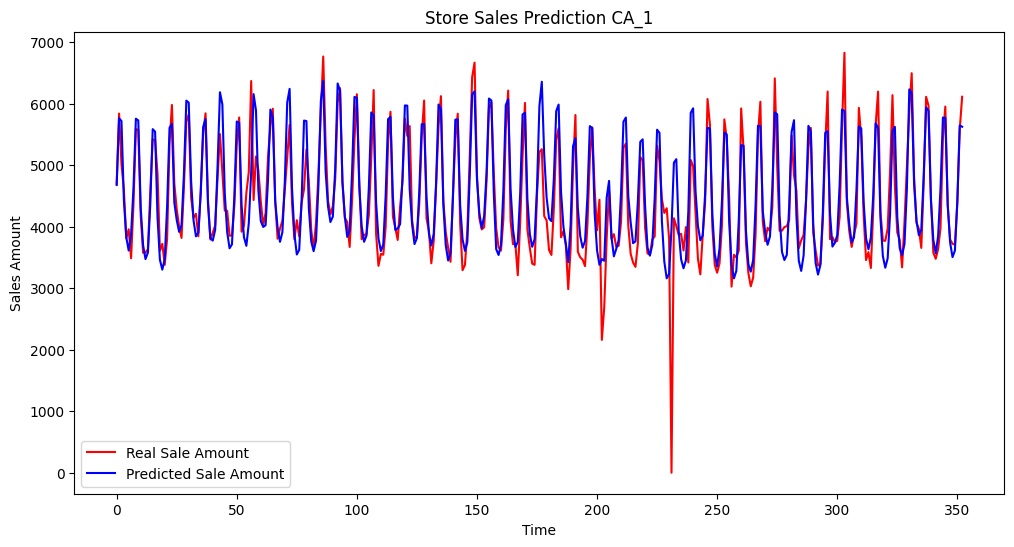

Train Done-----------------------------------------
Training begin CA_2--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 14ms/step - loss: 0.0574
Epoch 2/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0212
Epoch 3/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0172
Epoch 4/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0133
Epoch 5/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0086
Epoch 6/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0080
Epoch 7/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0068
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 14ms/step - loss: 0.0339
Epoch 2/8
47/47 [==============================] - 1s 16ms/step - loss: 0.0159
Epoch 3/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0114
Epoch 4/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0082
Epoch 5/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0073
Epoch 6/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0064
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0066
Epoch 8/8
47/47 [==============================] - 1s 5ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 13ms/step - loss: 0.0598
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0276
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0194
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0132
Epoch 5/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0091
Epoch 6/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0089
Epoch 7/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0073
Epoch 8/10
38/38 [==============================] - 1s 16ms/step - loss: 0.0064
Epoch 9/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0069
Epoch 10/10
38/38 [==============================] - 1s 6ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 4s 14ms/step - loss: 0.0487
Epoch 2/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0183
Epoch 3/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0162
Epoch 4/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0138
Epoch 5/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0117
Epoch 6/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0086
Epoch 7/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0073
Epoch 8/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0067
Epoch 9/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0067
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
94/94 [==============================] - 4s 14ms/step - loss: 0.0352
Epoch 2/10
94/94 [==============================] - 1s 13ms/step - loss: 0.0169
Epoch 3/10
94/94 [==============================] - 1s 13ms/step - loss: 0.0088
Epoch 4/10
94/94 [==============================] - 1s 14ms/step - loss: 0.0069
Epoch 5/10
94/94 [==============================] - 1s 14ms/step - loss: 0.0071
Epoch 6/10
94/94 [==============================] - 1s 15ms/step - loss: 0.0060
Epoch 7/10
94/94 [==============================] - 1s 16ms/step - loss: 0.0059
Epoch 8/10
94/94 [==============================] - 1s 16ms/step - loss: 0.0055
Epoch 9/10
94/94 [==============================] - 1s 15ms/step - loss: 0.0056
Epoch 10/10
12/12 [==============================] - 1s 6ms/step
Evaluation Metrics for Store CA_2:
RMSE: 0.2432
MAE: 0.2152
MAPE: 4.2154 or 421.54%
SMAPE: 29.49%
R²: -0.1733
NRMSE: 29.90%


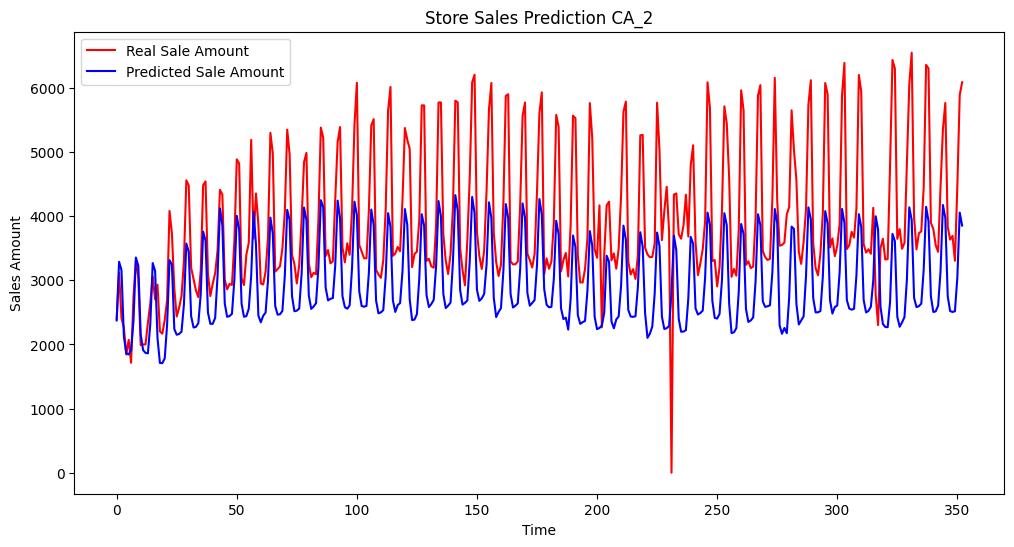

Train Done-----------------------------------------
Training begin CA_3--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 15ms/step - loss: 0.0388
Epoch 2/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0162
Epoch 3/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0135
Epoch 4/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0116
Epoch 5/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0104
Epoch 6/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0084
Epoch 7/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0076
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 16ms/step - loss: 0.0495
Epoch 2/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0132
Epoch 3/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0111
Epoch 4/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0089
Epoch 5/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0076
Epoch 6/8
47/47 [==============================] - 1s 16ms/step - loss: 0.0067
Epoch 7/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0062
Epoch 8/8
47/47 [==============================] - 1s 5ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 12ms/step - loss: 0.0594
Epoch 2/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0159
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0144
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0119
Epoch 5/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0100
Epoch 6/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0083
Epoch 7/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0087
Epoch 8/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0076
Epoch 9/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0069
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 11ms/step - loss: 0.0327
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0123
Epoch 3/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0096
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0091
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0074
Epoch 6/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0075
Epoch 7/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0067
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0069
Epoch 9/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0060
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
94/94 [==============================] - 3s 12ms/step - loss: 0.0236
Epoch 2/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0104
Epoch 3/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0077
Epoch 4/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0070
Epoch 5/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0069
Epoch 6/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0062
Epoch 7/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0062
Epoch 8/8
12/12 [==============================] - 1s 6ms/step
Evaluation Metrics for Store CA_3:
RMSE: 0.0677
MAE: 0.0485
MAPE: 3.9068 or 390.68%
SMAPE: 7.45%
R²: 0.6414
NRMSE: 10.05%


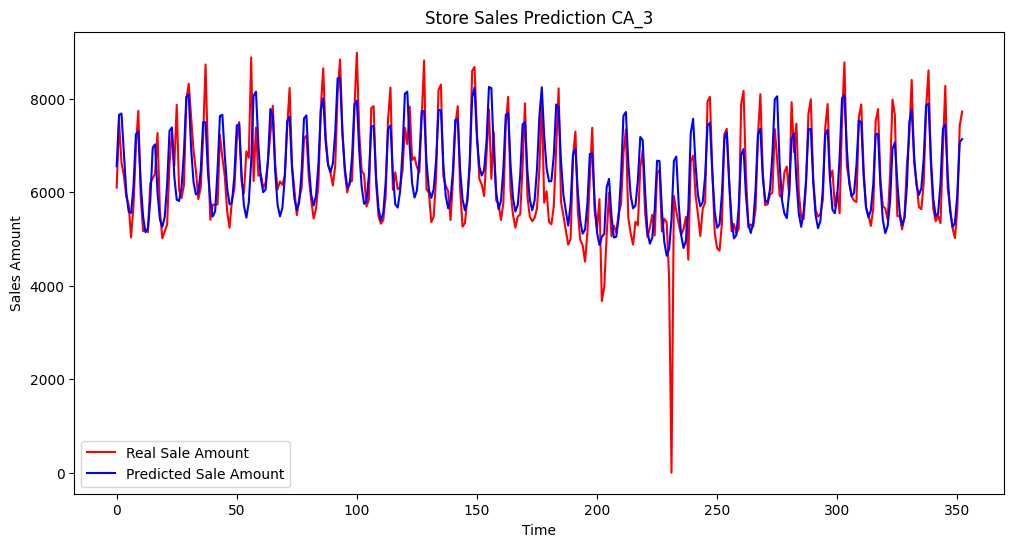

Train Done-----------------------------------------
Training begin CA_4--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 12ms/step - loss: 0.0369
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0139
Epoch 3/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0118
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0124
Epoch 5/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0090
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0094
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0083
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 12ms/step - loss: 0.0321
Epoch 2/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0110
Epoch 3/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0087
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0078
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0071
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0069
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0073
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 15ms/step - loss: 0.0663
Epoch 2/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0148
Epoch 3/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0129
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0109
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0106
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0092
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0084
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0072
Epoch 9/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0075
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 12ms/step - loss: 0.0760
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0138
Epoch 3/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0100
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0093
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0095
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0088
Epoch 7/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0088
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0072
Epoch 9/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0068
Epoch 10/10
38/38 [==============================] - 1s 6ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
75/75 [==============================] - 3s 9ms/step - loss: 0.0488
Epoch 2/8
75/75 [==============================] - 1s 9ms/step - loss: 0.0120
Epoch 3/8
75/75 [==============================] - 1s 9ms/step - loss: 0.0101
Epoch 4/8
75/75 [==============================] - 1s 9ms/step - loss: 0.0082
Epoch 5/8
75/75 [==============================] - 1s 10ms/step - loss: 0.0073
Epoch 6/8
75/75 [==============================] - 1s 9ms/step - loss: 0.0072
Epoch 7/8
75/75 [==============================] - 1s 9ms/step - loss: 0.0067
Epoch 8/8
12/12 [==============================] - 1s 5ms/step
Evaluation Metrics for Store CA_4:
RMSE: 0.0823
MAE: 0.0592
MAPE: 30936640964823868.0000 or 3093664096482386944.00%
SMAPE: 8.16%
R²: 0.2799
NRMSE: 11.01%


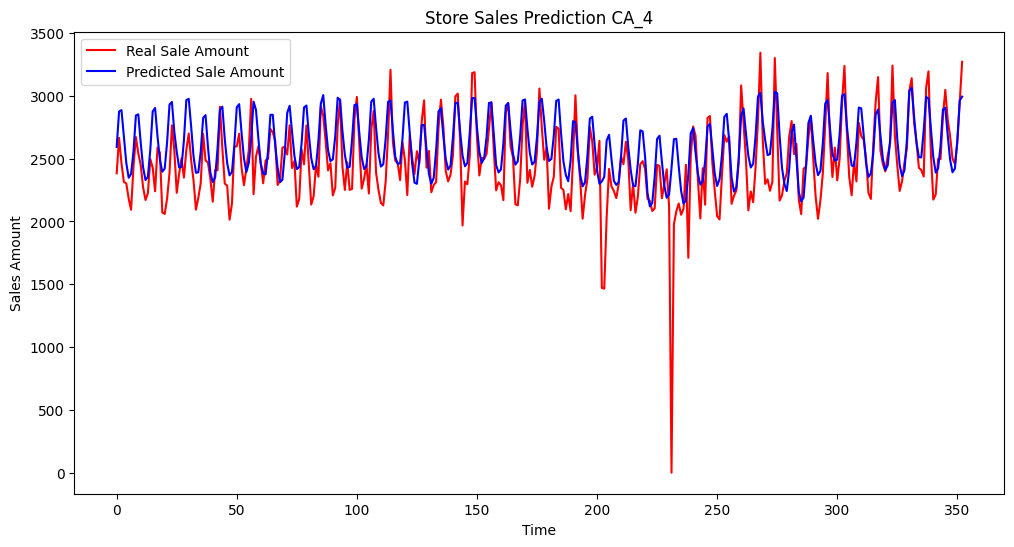

Train Done-----------------------------------------
Training begin TX_1--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 10ms/step - loss: 0.0504
Epoch 2/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0174
Epoch 3/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0147
Epoch 4/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0142
Epoch 5/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0105
Epoch 6/8
47/47 [==============================] - 1s 21ms/step - loss: 0.0094
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0086
Epoch 8/8
47/47 [==============================] - 1s 3ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 11ms/step - loss: 0.0250
Epoch 2/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0129
Epoch 3/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0113
Epoch 4/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0096
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0087
Epoch 6/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0078
Epoch 7/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0080
Epoch 8/8
47/47 [==============================] - 1s 3ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 12ms/step - loss: 0.0623
Epoch 2/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0176
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0153
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0135
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0119
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0097
Epoch 7/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0086
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0075
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0082
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 4s 14ms/step - loss: 0.0796
Epoch 2/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0153
Epoch 3/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0131
Epoch 4/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0118
Epoch 5/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0115
Epoch 6/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0095
Epoch 7/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0087
Epoch 8/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0082
Epoch 9/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0076
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
75/75 [==============================] - 3s 11ms/step - loss: 0.0262
Epoch 2/10
75/75 [==============================] - 1s 11ms/step - loss: 0.0135
Epoch 3/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0101
Epoch 4/10
75/75 [==============================] - 1s 11ms/step - loss: 0.0085
Epoch 5/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0074
Epoch 6/10
75/75 [==============================] - 1s 11ms/step - loss: 0.0072
Epoch 7/10
75/75 [==============================] - 1s 11ms/step - loss: 0.0070
Epoch 8/10
75/75 [==============================] - 1s 11ms/step - loss: 0.0069
Epoch 9/10
75/75 [==============================] - 1s 11ms/step - loss: 0.0066
Epoch 10/10
12/12 [==============================] - 1s 6ms/step
Evaluation Metrics for Store TX_1:
RMSE: 0.1025
MAE: 0.0802
MAPE: 7.3248 or 732.48%
SMAPE: 13.05%
R²: 0.2477
NRMSE: 15.28%


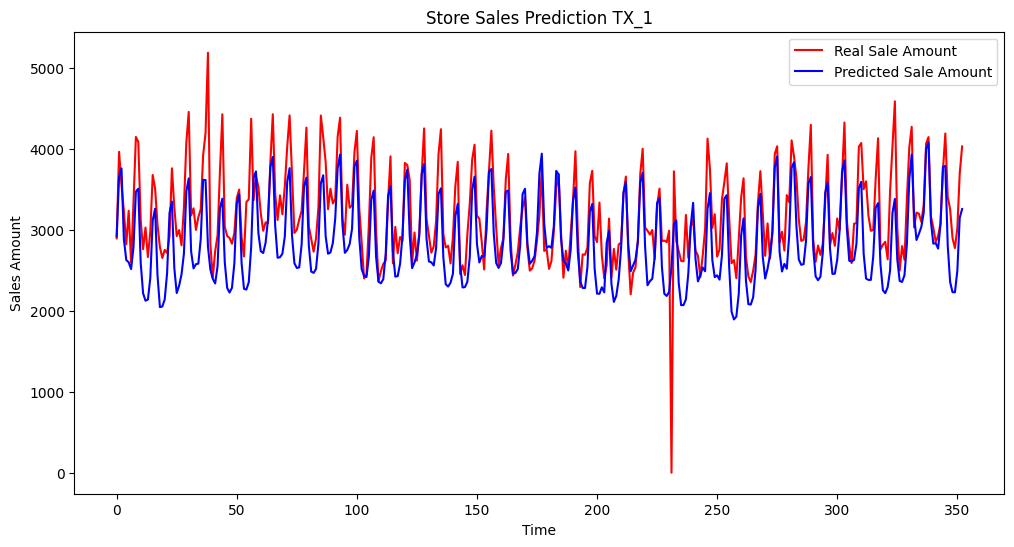

Train Done-----------------------------------------
Training begin TX_2--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 11ms/step - loss: 0.0423
Epoch 2/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0196
Epoch 3/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0154
Epoch 4/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0118
Epoch 5/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0102
Epoch 6/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0090
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0085
Epoch 8/8
47/47 [==============================] - 1s 6ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 12ms/step - loss: 0.0292
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0143
Epoch 3/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0126
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0104
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0086
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0082
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0077
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 13ms/step - loss: 0.0469
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0169
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0140
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0116
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0100
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0086
Epoch 7/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0075
Epoch 8/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0079
Epoch 9/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0073
Epoch 10/10
38/38 [==============================] - 1s 6ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 13ms/step - loss: 0.0418
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0163
Epoch 3/10
38/38 [==============================] - 1s 17ms/step - loss: 0.0134
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0117
Epoch 5/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0098
Epoch 6/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0088
Epoch 7/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0091
Epoch 8/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0081
Epoch 9/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0073
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
94/94 [==============================] - 4s 13ms/step - loss: 0.0371
Epoch 2/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0133
Epoch 3/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0106
Epoch 4/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0083
Epoch 5/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0080
Epoch 6/8
94/94 [==============================] - 1s 12ms/step - loss: 0.0069
Epoch 7/8
94/94 [==============================] - 1s 14ms/step - loss: 0.0072
Epoch 8/8
12/12 [==============================] - 1s 11ms/step
Evaluation Metrics for Store TX_2:
RMSE: 0.0984
MAE: 0.0780
MAPE: 41277890448077136.0000 or 4127789044807713792.00%
SMAPE: 13.07%
R²: 0.1669
NRMSE: 15.87%


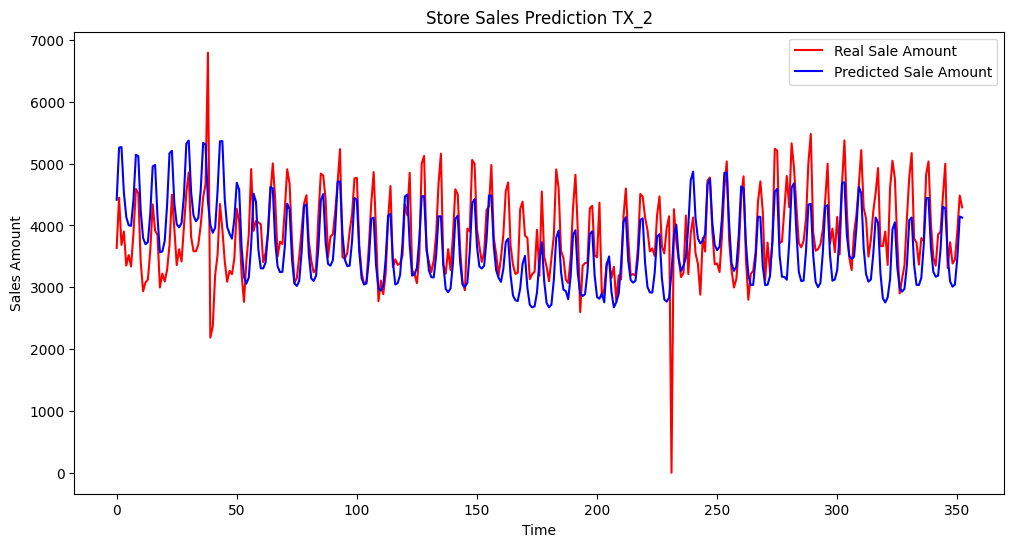

Train Done-----------------------------------------
Training begin TX_3--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 16ms/step - loss: 0.0320
Epoch 2/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0156
Epoch 3/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0119
Epoch 4/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0097
Epoch 5/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0101
Epoch 6/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0080
Epoch 7/8
47/47 [==============================] - 1s 15ms/step - loss: 0.0082
Epoch 8/8
47/47 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 15ms/step - loss: 0.0292
Epoch 2/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0113
Epoch 3/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0095
Epoch 4/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0076
Epoch 5/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0073
Epoch 6/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0066
Epoch 7/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0065
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 11ms/step - loss: 0.0855
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0182
Epoch 3/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0151
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0133
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0120
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0104
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0089
Epoch 8/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0086
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0084
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 12ms/step - loss: 0.0223
Epoch 2/10
38/38 [==============================] - 0s 10ms/step - loss: 0.0128
Epoch 3/10
38/38 [==============================] - 0s 10ms/step - loss: 0.0110
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0097
Epoch 5/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0086
Epoch 6/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0073
Epoch 7/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0069
Epoch 8/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0069
Epoch 9/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0059
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
75/75 [==============================] - 3s 8ms/step - loss: 0.0326
Epoch 2/10
75/75 [==============================] - 1s 8ms/step - loss: 0.0129
Epoch 3/10
75/75 [==============================] - 1s 8ms/step - loss: 0.0102
Epoch 4/10
75/75 [==============================] - 1s 8ms/step - loss: 0.0083
Epoch 5/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0076
Epoch 6/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0069
Epoch 7/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0071
Epoch 8/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0065
Epoch 9/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0065
Epoch 10/10
12/12 [==============================] - 1s 9ms/step
Evaluation Metrics for Store TX_3:
RMSE: 0.0894
MAE: 0.0625
MAPE: 3.2480 or 324.80%
SMAPE: 8.72%
R²: 0.4205
NRMSE: 11.86%


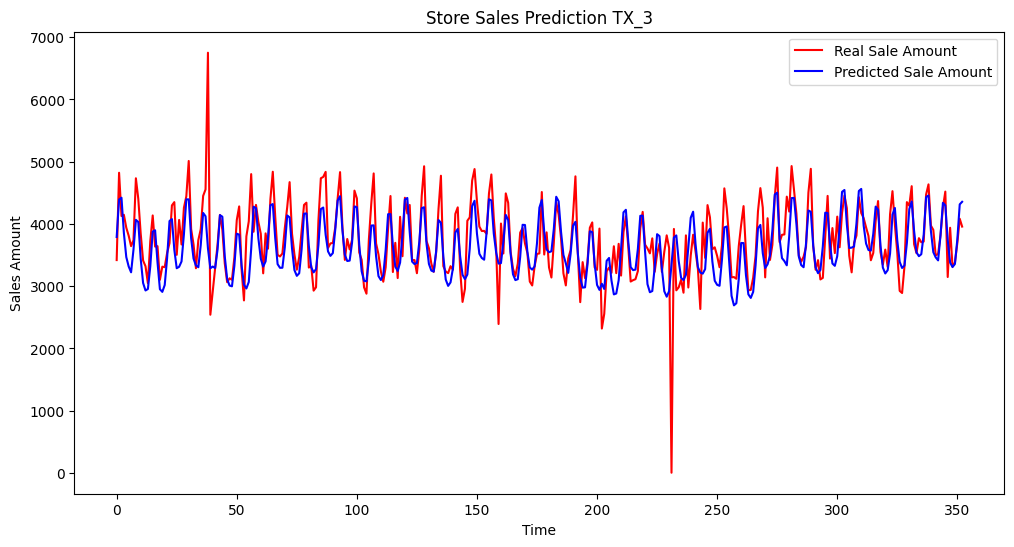

Train Done-----------------------------------------
Training begin WI_1--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 13ms/step - loss: 0.0438
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0133
Epoch 3/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0107
Epoch 4/8
47/47 [==============================] - 1s 13ms/step - loss: 0.0094
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0072
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0061
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0063
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 11ms/step - loss: 0.0155
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0072
Epoch 3/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0058
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0046
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0041
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0036
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0032
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 11ms/step - loss: 0.0264
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0136
Epoch 3/10
38/38 [==============================] - 0s 10ms/step - loss: 0.0106
Epoch 4/10
38/38 [==============================] - 0s 10ms/step - loss: 0.0088
Epoch 5/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0071
Epoch 6/10
38/38 [==============================] - 0s 10ms/step - loss: 0.0056
Epoch 7/10
38/38 [==============================] - 0s 10ms/step - loss: 0.0052
Epoch 8/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0052
Epoch 9/10
38/38 [==============================] - 0s 10ms/step - loss: 0.0049
Epoch 10/10
38/38 [==============================] - 1s 3ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 3s 12ms/step - loss: 0.0187
Epoch 2/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0079
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0059
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0053
Epoch 5/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0047
Epoch 6/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0041
Epoch 7/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0037
Epoch 8/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0035
Epoch 9/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0032
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
94/94 [==============================] - 3s 10ms/step - loss: 0.0136
Epoch 2/10
94/94 [==============================] - 1s 10ms/step - loss: 0.0071
Epoch 3/10
94/94 [==============================] - 1s 10ms/step - loss: 0.0054
Epoch 4/10
94/94 [==============================] - 1s 10ms/step - loss: 0.0047
Epoch 5/10
94/94 [==============================] - 1s 12ms/step - loss: 0.0042
Epoch 6/10
94/94 [==============================] - 1s 12ms/step - loss: 0.0040
Epoch 7/10
94/94 [==============================] - 1s 12ms/step - loss: 0.0038
Epoch 8/10
94/94 [==============================] - 1s 12ms/step - loss: 0.0037
Epoch 9/10
94/94 [==============================] - 1s 11ms/step - loss: 0.0034
Epoch 10/10
12/12 [==============================] - 1s 4ms/step
Evaluation Metrics for Store WI_1:
RMSE: 0.0680
MAE: 0.0477
MAPE: 5.3741 or 537.41%
SMAPE: 9.49%
R²: 0.6586
NRMSE: 13.06%


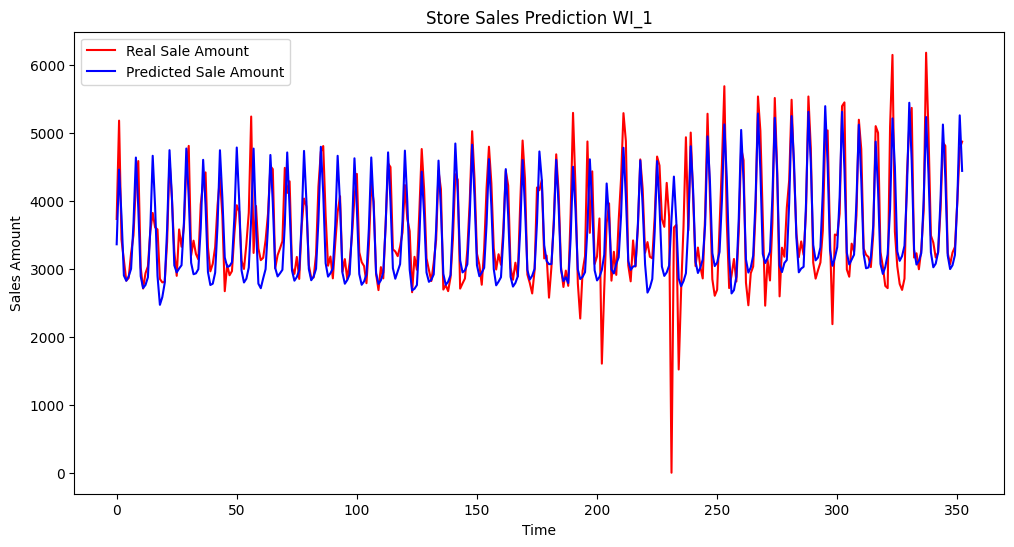

Train Done-----------------------------------------
Training begin WI_2--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 4s 12ms/step - loss: 0.0316
Epoch 2/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0174
Epoch 3/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0154
Epoch 4/8
47/47 [==============================] - 0s 11ms/step - loss: 0.0133
Epoch 5/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0140
Epoch 6/8
47/47 [==============================] - 0s 11ms/step - loss: 0.0131
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0115
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 11ms/step - loss: 0.0199
Epoch 2/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0087
Epoch 3/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0084
Epoch 4/8
47/47 [==============================] - 0s 11ms/step - loss: 0.0079
Epoch 5/8
47/47 [==============================] - 0s 10ms/step - loss: 0.0086
Epoch 6/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0077
Epoch 7/8
47/47 [==============================] - 0s 11ms/step - loss: 0.0065
Epoch 8/8
47/47 [==============================] - 1s 3ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 11ms/step - loss: 0.0718
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0237
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0178
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0172
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0155
Epoch 6/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0137
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0140
Epoch 8/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0127
Epoch 9/10
38/38 [==============================] - 1s 15ms/step - loss: 0.0119
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 4s 13ms/step - loss: 0.0264
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0100
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0080
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0081
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0075
Epoch 6/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0067
Epoch 7/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0070
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0065
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0073
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
94/94 [==============================] - 3s 11ms/step - loss: 0.0190
Epoch 2/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0124
Epoch 3/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0105
Epoch 4/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0100
Epoch 5/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0106
Epoch 6/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0084
Epoch 7/8
94/94 [==============================] - 1s 11ms/step - loss: 0.0080
Epoch 8/8
12/12 [==============================] - 1s 7ms/step
Evaluation Metrics for Store WI_2:
RMSE: 0.0992
MAE: 0.0747
MAPE: 10.7513 or 1075.13%
SMAPE: 10.64%
R²: 0.6230
NRMSE: 13.63%


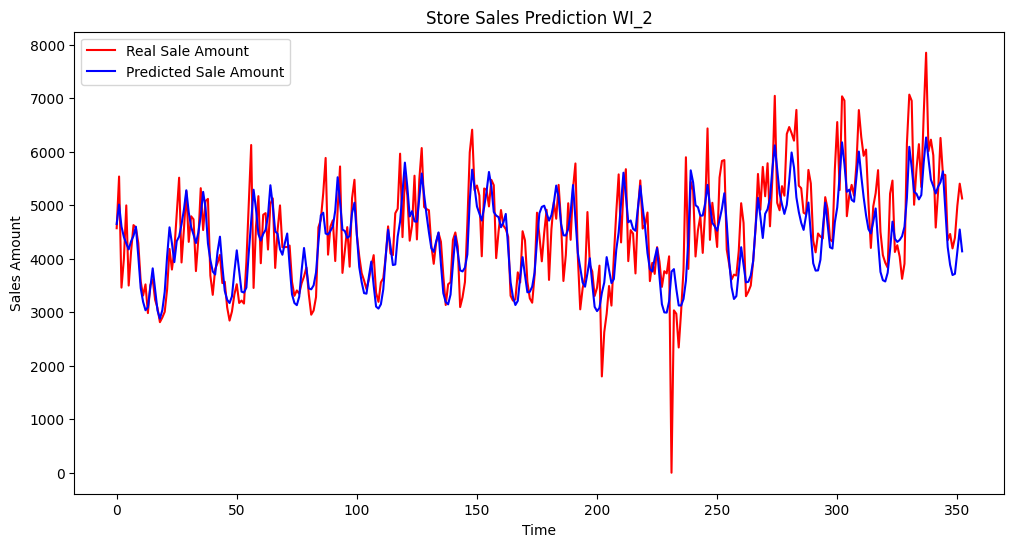

Train Done-----------------------------------------
Training begin WI_3--------------------------------


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 13ms/step - loss: 0.0280
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0118
Epoch 3/8
47/47 [==============================] - 1s 14ms/step - loss: 0.0101
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0085
Epoch 5/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0063
Epoch 6/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0057
Epoch 7/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0058
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/8
47/47 [==============================] - 3s 11ms/step - loss: 0.0982
Epoch 2/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0198
Epoch 3/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0170
Epoch 4/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0176
Epoch 5/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0140
Epoch 6/8
47/47 [==============================] - 1s 12ms/step - loss: 0.0116
Epoch 7/8
47/47 [==============================] - 1s 11ms/step - loss: 0.0105
Epoch 8/8
47/47 [==============================] - 1s 4ms/step


...

Epoch 1/10
38/38 [==============================] - 3s 11ms/step - loss: 0.0323
Epoch 2/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0111
Epoch 3/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0097
Epoch 4/10
38/38 [==============================] - 0s 11ms/step - loss: 0.0093
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0076
Epoch 6/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0071
Epoch 7/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0074
Epoch 8/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0066
Epoch 9/10
38/38 [==============================] - 0s 13ms/step - loss: 0.0057
Epoch 10/10
38/38 [==============================] - 1s 4ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
38/38 [==============================] - 4s 14ms/step - loss: 0.0422
Epoch 2/10
38/38 [==============================] - 1s 13ms/step - loss: 0.0171
Epoch 3/10
38/38 [==============================] - 1s 14ms/step - loss: 0.0153
Epoch 4/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0132
Epoch 5/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0116
Epoch 6/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0104
Epoch 7/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0093
Epoch 8/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0095
Epoch 9/10
38/38 [==============================] - 0s 12ms/step - loss: 0.0100
Epoch 10/10
38/38 [==============================] - 1s 5ms/step


d:\Program\Anaconda\envs\tensorflow\lib\site-packages\scikeras\wrappers.py:915: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)


Epoch 1/10
75/75 [==============================] - 3s 9ms/step - loss: 0.0368
Epoch 2/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0143
Epoch 3/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0105
Epoch 4/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0091
Epoch 5/10
75/75 [==============================] - 1s 9ms/step - loss: 0.0074
Epoch 6/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0082
Epoch 7/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0076
Epoch 8/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0068
Epoch 9/10
75/75 [==============================] - 1s 10ms/step - loss: 0.0068
Epoch 10/10
12/12 [==============================] - 1s 5ms/step
Evaluation Metrics for Store WI_3:
RMSE: 0.0943
MAE: 0.0713
MAPE: 8.6326 or 863.26%
SMAPE: 12.62%
R²: 0.4085
NRMSE: 16.23%


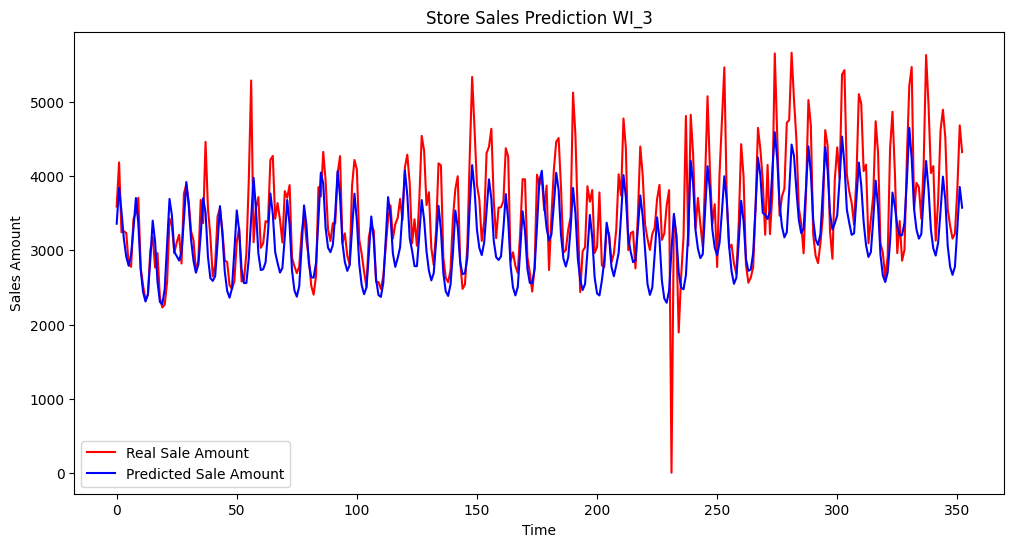

Train Done-----------------------------------------

Metrics Comparison Across All Stores:
          RMSE       MAE          MAPE      SMAPE        R²      NRMSE
CA_1  0.066676  0.046915  5.074494e+16   7.663213  0.739163  10.445709
CA_2  0.243236  0.215200  4.215437e+00  29.486843 -0.173286  29.903914
CA_3  0.067680  0.048453  3.906793e+00   7.446280  0.641405  10.046099
CA_4  0.082347  0.059213  3.093664e+16   8.161175  0.279876  11.013972
TX_1  0.102546  0.080185  7.324780e+00  13.050802  0.247711  15.281638
TX_2  0.098375  0.078030  4.127789e+16  13.071282  0.166880  15.867898
TX_3  0.089381  0.062518  3.247971e+00   8.723706  0.420503  11.859556
WI_1  0.068041  0.047727  5.374146e+00   9.490314  0.658580  13.057803
WI_2  0.099156  0.074709  1.075135e+01  10.635308  0.622959  13.625257
WI_3  0.094330  0.071344  8.632555e+00  12.620374  0.408522  16.225627


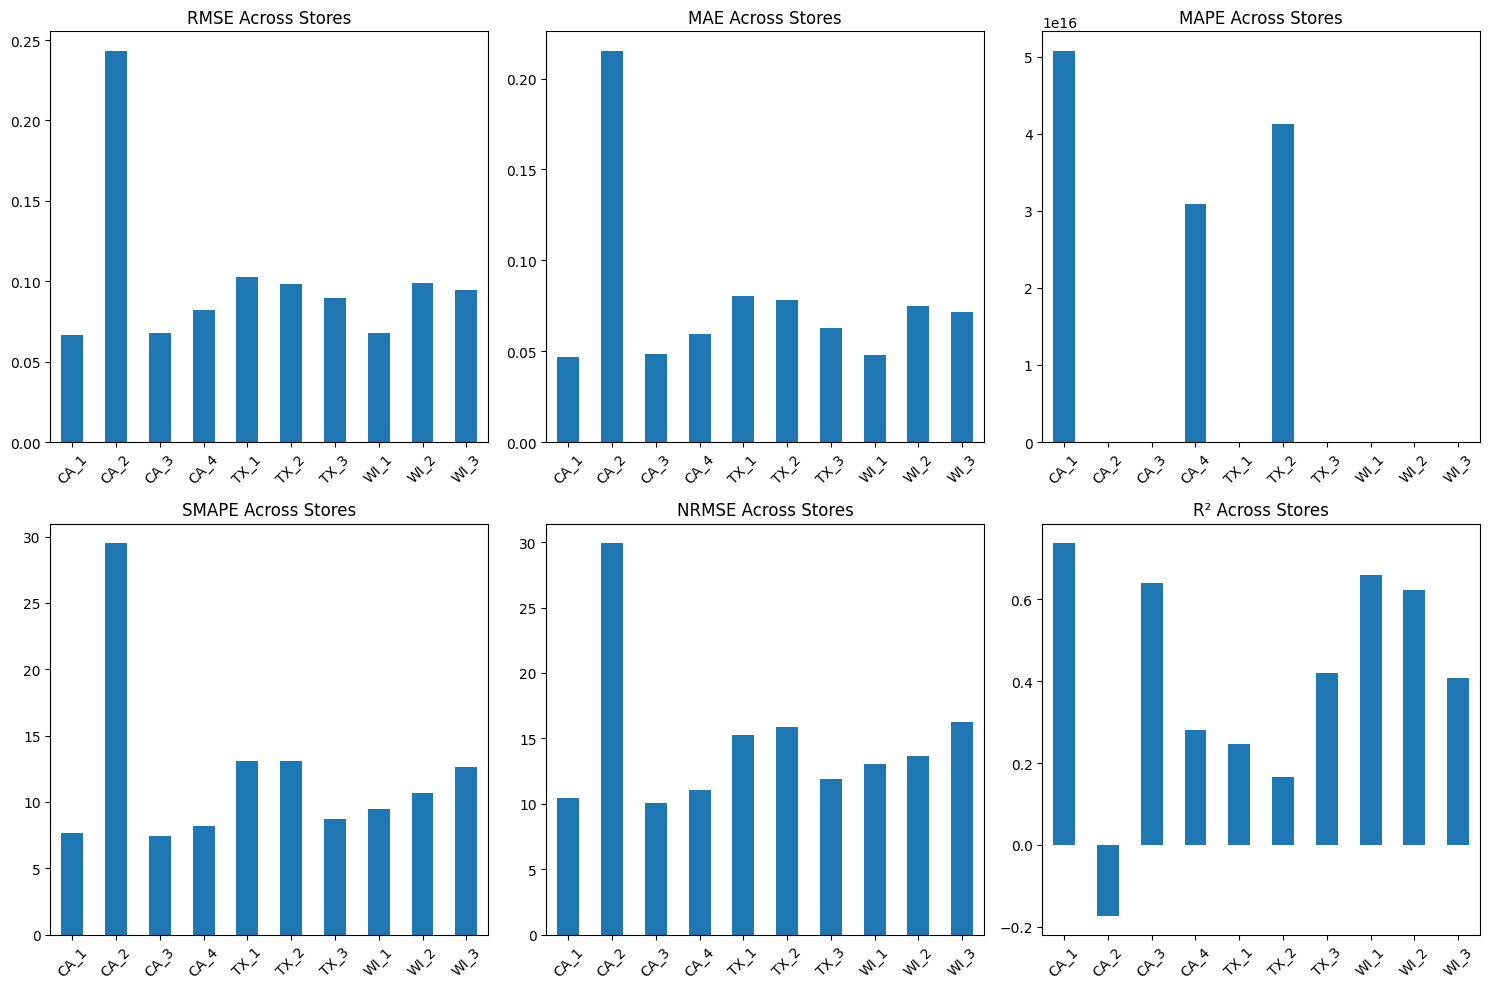

In [ ]:
#%%

dir = "../data/df_encoded.csv"
df = pd.read_csv(dir)
store_list = df["store_id"].unique()
scaler = MinMaxScaler(feature_range=(0,1))
metrics_results = {}

for store in store_list:
    print(f"Training begin {store}--------------------------------")
    trainX, trainY, testX, testY = prepare_data(dir, store)
    grid_search = train_model(build_model, trainX, trainY)
    my_model = grid_search.best_estimator_.model_
    
    # Make predictions
    predictions = my_model.predict(testX)
    
    # Inverse transform for actual values (same as your original code)
    prediction_copies_array = np.repeat(predictions, 64, axis=-1)
    pred = scaler.inverse_transform(np.reshape(prediction_copies_array, (len(predictions), 64)))[:,0]
    
    original_copies_array = np.repeat(testY, 64, axis=-1)
    original = scaler.inverse_transform(np.reshape(original_copies_array, (len(testY), 64)))[:,0]
    
    # Calculate multiple evaluation metrics
    # 1. RMSE - Root Mean Squared Error
    rmse = np.sqrt(mean_squared_error(testY, predictions))
    
    # 2. MAE - Mean Absolute Error
    mae = mean_absolute_error(testY, predictions)
    
    # 3. MAPE - Mean Absolute Percentage Error (on original scale)
    # Avoiding division by zero
    mape = mean_absolute_percentage_error(original, pred)
    
    # 4. R² - Coefficient of Determination
    r2 = r2_score(testY, predictions)
    
    # 5. NRMSE - Normalized RMSE (as percentage of the mean)
    nrmse = rmse / np.mean(testY) * 100
    
    # 6. SMAPE - Symmetric Mean Absolute Percentage Error
    smape = 100/len(original) * np.sum(2 * np.abs(pred - original) / (np.abs(original) + np.abs(pred)))
    
    # Store all metrics
    metrics_results[store] = {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape,
        'SMAPE': smape,
        'R²': r2,
        'NRMSE': nrmse
    }
    
    # Print metrics
    print(f"Evaluation Metrics for Store {store}:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MAPE: {mape:.4f} or {mape*100:.2f}%")
    print(f"SMAPE: {smape:.2f}%")
    print(f"R²: {r2:.4f}")
    print(f"NRMSE: {nrmse:.2f}%")
    
    # Plot actual vs predicted values (same as your original code)
    plt.figure(figsize=(12, 6))
    plt.plot(original, color='red', label='Real Sale Amount')
    plt.plot(pred, color='blue', label='Predicted Sale Amount')
    plt.title(f'Store Sales Prediction {store}')
    plt.xlabel('Time')
    plt.ylabel('Sales Amount')
    plt.legend()
    plt.show()
    
    print("Train Done-----------------------------------------")

# Create a comparison table of metrics across all stores
metrics_df = pd.DataFrame(metrics_results).T
print("\nMetrics Comparison Across All Stores:")
print(metrics_df)

# Plot metrics comparison
plt.figure(figsize=(15, 10))
metrics_to_plot = ['RMSE', 'MAE', 'MAPE', 'SMAPE', 'NRMSE']

for i, metric in enumerate(metrics_to_plot, 1):
    plt.subplot(2, 3, i)
    metrics_df[metric].plot(kind='bar')
    plt.title(f'{metric} Across Stores')
    plt.xticks(rotation=45)
    plt.tight_layout()

# Plot R² separately (as it has a different scale)
plt.subplot(2, 3, 6)
metrics_df['R²'].plot(kind='bar')
plt.title('R² Across Stores')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('metrics_comparison.png')
plt.show()